In this notebook we analyse the regret for each method proposed to solve policy control when rewards are delayed, aggregate and anonymous.

To measure regret, we use a policy learned with full reward information each time step.

The measure of comparison is the average return over all runs at the final episode $K_{max}$, $G_{avg,K_{max}} = \frac{1}{K_{max}}\sum^{K_{max}}_{K=1} G_{k}$.

Then we average that across runs, and compute the returns ratio as: $\frac{\mu_{\bar{G}^{m}_{K}} - \mu_{\bar{G}^{FR}_{K}}}{\vert \mu_{\bar{G}^{FR}_{K}} \rvert}$.
It tells us the percentage difference in average return between the policy trained with algorithm $m$ compared to the full rewards policy.
Lower is better.

Key on methods:

  - "PP/FR": Full rewards information
  - "PP/IMR": Impute missing rewards (zero when absent)
  - "PP/LEAST-LFA": Reward estimation
  - "OP-A/FR": Options policy, with composition actions as options
  - "OP-S/FR": Options policy, with repeated single action as options

In [1]:
import copy
import os
import pathlib
from typing import Set, Mapping, Sequence
import itertools
import functools

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import stats

In [3]:
import matplotlib
from matplotlib import pyplot as plt

In [4]:
from drmdp import dataproc

In [5]:
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [6]:
import warnings  # To suppress some warnings

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [7]:
files = tf.io.gfile.glob(
    f"{pathlib.Path.home()}/fs/drmdp/workflows/controljob/agg/1772983724/1772992432/metrics/*.parquet"
)

In [8]:
df_metrics = dataproc.read_data(files, reader="pd")

In [9]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [10]:
df_metrics.iloc[0]["meta"]

{'context': {'dummy': 0},
 'exp_id': '1772983724-0067d357-Finite-CC-ShuntDc-v0',
 'export_model': True,
 'instance_id': 0,
 'run_config': {'episodes_per_run': 500,
  'log_episode_frequency': 10,
  'num_runs': 20,
  'output_dir': 'gs://mo-hendrix-ml-workflows-storage/drmdp/workflows/controljob/logs/1772983724/1772983724-0067d357-Finite-CC-ShuntDc-v0/run_0/identity/cfc91fc9',
  'use_seed': True},
 'env_spec': {'args': {'constraint_violation_reward': -10.0,
   'emit_state': False,
   'max_episode_steps': 10000,
   'penalty_gamma': 1.0,
   'reward_fn': 'pos-enf'},
  'feats_spec': array([{'args': {'tiling_dim': 3.0}, 'name': 'tile-observation-action-ft'}],
        dtype=object),
  'name': 'Finite-CC-ShuntDc-v0'},
 'epochs': 1,
 'problem_spec': {'delay_config': None,
  'epsilon': 0.1,
  'gamma': 0.99,
  'learning_rate_config': {'args': {'initial_lr': 0.01}, 'name': 'constant'},
  'policy_type': 'markovian',
  'reward_mapper': {'args': None, 'name': 'identity'}},
 'reward_mapper': 'FR',
 'pol

In [11]:
df_metrics

,episode,exp_id,meta,returns,steps,metrics,method
0,390,1772983724-0067d357-Finite-CC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11425.588676040405, 11855.309485639467, 11906...","[10000, 10000, 854, 10000, 10000, 5985, 6795, ...","{'returns': {'mean': 11501.326835673426, 'std'...",FR
3,390,1772983724-0519c138-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[11738.834433644248, 10928.992765198936, 11132...","[6572, 4215, 3379, 7948, 10000, 6324, 3098, 10...","{'returns': {'mean': 10026.432969495087, 'std'...",BLADE-TD
4,390,1772983724-0561605a-Finite-SC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1050.724894112128, 820.7110265811008, 939.221...","[328, 1526, 455, 636, 361, 1179, 246, 266, 185...","{'returns': {'mean': 1021.7995423610597, 'std'...",IMR
7,390,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[6786.188323206214, 7923.673874855165, 7579.95...","[5039, 3761, 53, 7662, 10000, 138, 10000, 1314...","{'returns': {'mean': 7116.390955422966, 'std':...",IMR
8,390,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[224.84979924568395, 1343.1712552824158, 277.9...","[3491, 243, 36, 8, 11, 1541, 1554, 7, 41, 7, 2...","{'returns': {'mean': 578.71541393419, 'std': 5...",DMR
...,...,...,...,...,...,...,...
245,210,1772983724-f768ece2-Finite-CC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[129.2177113574301, 141.91227011151037, 175.87...","[101, 77, 36, 117, 28, 31, 11, 29, 77, 24, 237...","{'returns': {'mean': 146.78908431076604, 'std'...",OP-A
248,210,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[2393.457856081534, 2075.1664275337844, 2451.7...","[9, 102, 8, 14, 8, 108, 6579, 7, 7, 2964, 1761...","{'returns': {'mean': 1463.7337672035012, 'std'...",DMR
249,210,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[7978.698568076154, 8269.575630667052, 7661.57...","[8582, 197, 6783, 3370, 10000, 3020, 1954, 334...","{'returns': {'mean': 7074.941044575697, 'std':...",IMR
250,210,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[1178.4924371012733, 1210.7621488027414, 1170....","[222, 590, 664, 638, 548, 4592, 388, 1108, 108...","{'returns': {'mean': 1335.9234477657872, 'std'...",BLADE-TD


In [12]:
envs = dataproc.get_distinct_envs(df_metrics)

In [13]:
envs

{'Finite-CC-ShuntDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': False,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'Finite-CC-PermExDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': False,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'Finite-SC-PermExDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': False,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'Finite-TC-PermExDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': False,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'Finite-SC-ShuntDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': True,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'pos-enf'},
 'Finite-TC-ShuntDc-v0': {'constraint_violation_reward': -10.0,
  'emit_state': True,
  'max_episode_steps': 10000,
  'penalty_gamma': 1.0,
  'reward_fn': 'po

In [14]:
METHODS = sorted(df_metrics["method"].unique())

In [15]:
METHODS

['BLADE-TD', 'BLADE-TD[N-B]', 'DMR', 'FR', 'IMR', 'OP-A']

In [16]:
def parse_delay_config(df_input: pd.DataFrame):
    df = copy.deepcopy(df_input)

    def parse_mu(delay_config):
        if delay_config is None:
            return None
        args = delay_config["args"]
        try:
            return args["delay"]
        except KeyError:
            return args["lam"]
        except KeyError as exc:
            raise ValueError(f"Unknown delay config {args}") from exc

    df["delay_type"] = df["delay_config"].apply(lambda dc: dc["name"] if dc else None)
    df["delay_mu"] = df["delay_config"].apply(parse_mu)
    del df["delay_config"]
    return df

In [17]:
def max_episode_filter(df_input):
    env_spec = df_input["meta"].apply(lambda meta: meta["env_spec"])
    env_name = env_spec.apply(lambda spec: spec["name"])
    envs = env_name.unique()
    dfs = []
    for env in envs:
        df_slice = df_input[(env_name == env)]
        df_slice = df_slice[df_slice["episode"] == df_slice["episode"].max()]
        dfs.append(copy.deepcopy(df_slice))
    return pd.concat(dfs)

In [18]:
def parse_specs(xs, scope: str, col: str):
    if isinstance(xs, Mapping):
        return xs[col]
    values = tuple(el[col] for el in xs)
    if scope == "feats":
        if col == "name":
            return dataproc.FEAT_PROCS[values[0]]
        return values[0]
    return values

In [19]:
def extract_salient_meta_fields(df_data: pd.DataFrame):
    df_raw = copy.deepcopy(df_data)
    specs = {
        "env": df_raw["meta"].apply(lambda meta: meta["env_spec"]),
        "feats": df_raw["meta"].apply(lambda meta: meta["env_spec"]["feats_spec"]),
    }
    for prefix, col_fam in specs.items():
        for col in ("name", "args"):
            df_raw[f"{prefix}_{col}"] = col_fam.apply(
                functools.partial(parse_specs, scope=prefix, col=col)
        )
    for key in (
        "delay_config",
        "gamma",
    ):
        df_raw[key] = df_raw["meta"].apply(lambda meta: meta["problem_spec"][key])
    return parse_delay_config(df_raw)

## Regret - Relative to full rewards observation

In [20]:
def calculate_regret_over_configurations(df_data):
    def calc_regret(y_pred, y_oracle):
        # agg returns
        mean_y_oracle = np.mean(y_oracle)
        return (np.mean(y_pred) - mean_y_oracle) / np.abs(mean_y_oracle)

    df_result = max_episode_filter(df_data)
    df_result = extract_salient_meta_fields(df_result)

    df_baseline = df_result[pd.isnull(df_result["delay_type"])]
    df_result = df_result[~pd.isnull(df_result["delay_type"])]

    baselines = {}
    keys = ["env_name", "gamma", "delay_config"]
    for row in df_baseline.to_dict("records"):
        key = tuple(row[key] for key in keys[:-1])
        baselines[key] = row["returns"]

    for key in sorted(baselines.keys()):
        print(key)

    rows = []
    for row in df_result.to_dict("records"):
        key = tuple([row[key] for key in keys[:-1]])
        full_reward_mean_return = baselines[key]
        regret = calc_regret(y_pred=row["returns"], y_oracle=full_reward_mean_return)
        row["relative_regret"] = regret
        row["method"] = row["method"]
        rows.append(row)

    df_regret = pd.DataFrame(rows)
    df_regret = df_regret[
        ["env_name", "method", "delay_type", "delay_mu", "relative_regret"]
    ].sort_values(["env_name", "method", "delay_type", "delay_mu"])
    return {"sarsa": df_regret}

In [21]:
METHODS_PALETTES = {
    key: palette for key, palette in zip(dataproc.ORDERED_METHODS, sns.color_palette())
}

In [22]:
METHODS_PALETTES

{'BLADE-TD': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'BLADE-TD[N-B]': (1.0, 0.4980392156862745, 0.054901960784313725),
 'IMR': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'OP-A': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'OP-S': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'DMR': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'FR': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)}

In [23]:
def plot_regret(
    df_data, suffix=None, method_filter_fn=lambda met: True, output_dir="figures/regret"
):
    df_raw = copy.deepcopy(
        df_data[["env_name", "method", "delay_type", "delay_mu", "relative_regret"]]
    )
    df_raw = df_raw[df_raw["method"].apply(method_filter_fn)]
    rps = sorted(df_raw["delay_mu"].unique())

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(rps),
        figsize=(4 * len(rps), 4),
        sharey=False,
    )

    legend_shown = False
    for ax, rp in zip(axes.flatten(), rps):
        df_plot = df_raw[df_raw["delay_mu"] == rp]
        sns.boxplot(
            df_plot,
            x="env_name",
            y="relative_regret",
            hue="method",
            palette=METHODS_PALETTES,
            fill=False,
            ax=ax,
        )
        ax.tick_params(axis="x", labelrotation=90)
        ax.set_xlabel("Environment")
        ax.set_title(f"Reward Delay, P = {rp}")
        if legend_shown is False:
            legend_shown = True
            ax.set_ylabel("Returns Ratio")
            ax.legend(
                loc="upper center",
                bbox_to_anchor=(len(rps) / 2.0, 1.3),
                ncol=3,
                fancybox=True,
            )
        else:
            ax.set(ylabel=None)
            ax.legend().set_visible(False)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    name = f"regret_{suffix}.pdf"
    path = os.path.join(output_dir, name)
    plt.savefig(path, dpi=300, format="pdf", bbox_inches="tight")

In [24]:
dfs_regret = calculate_regret_over_configurations(df_metrics)

('Finite-CC-PermExDc-v0', 0.99)
('Finite-CC-PermExDc-v0', 1.0)
('Finite-CC-ShuntDc-v0', 0.99)
('Finite-CC-ShuntDc-v0', 1.0)
('Finite-SC-PermExDc-v0', 0.99)
('Finite-SC-PermExDc-v0', 1.0)
('Finite-SC-ShuntDc-v0', 0.99)
('Finite-SC-ShuntDc-v0', 1.0)
('Finite-TC-PermExDc-v0', 0.99)
('Finite-TC-PermExDc-v0', 1.0)
('Finite-TC-ShuntDc-v0', 0.99)
('Finite-TC-ShuntDc-v0', 1.0)


In [25]:
dfs_regret["sarsa"]

,env_name,method,delay_type,delay_mu,relative_regret
36,Finite-CC-PermExDc-v0,BLADE-TD,clipped-poisson,2.0,0.027551
61,Finite-CC-PermExDc-v0,BLADE-TD,clipped-poisson,2.0,-0.055537
53,Finite-CC-PermExDc-v0,BLADE-TD,clipped-poisson,4.0,0.050678
57,Finite-CC-PermExDc-v0,BLADE-TD,clipped-poisson,4.0,-0.013860
50,Finite-CC-PermExDc-v0,BLADE-TD,clipped-poisson,6.0,0.071268
...,...,...,...,...,...
213,Finite-TC-ShuntDc-v0,IMR,clipped-poisson,8.0,-0.127338
192,Finite-TC-ShuntDc-v0,OP-A,clipped-poisson,2.0,-0.987233
193,Finite-TC-ShuntDc-v0,OP-A,clipped-poisson,2.0,-0.904069
185,Finite-TC-ShuntDc-v0,OP-A,clipped-poisson,4.0,-0.887494


In [26]:
dfs_regret["sarsa"]["env_name"].unique()

array(['Finite-CC-PermExDc-v0', 'Finite-CC-ShuntDc-v0',
       'Finite-SC-PermExDc-v0', 'Finite-SC-ShuntDc-v0',
       'Finite-TC-PermExDc-v0', 'Finite-TC-ShuntDc-v0'], dtype=object)

In [27]:
sorted(dfs_regret["sarsa"]["delay_mu"].unique())

[2.0, 4.0, 6.0, 8.0]

In [28]:
dfs_regret["sarsa"].dtypes

env_name            object
method              object
delay_type          object
delay_mu           float64
relative_regret    float64
dtype: object

In [29]:
def filter_envs(df_input, envs: Set[str]):
    mask = df_input["env_name"].apply(lambda name: name in envs)
    return copy.copy(df_input[mask])

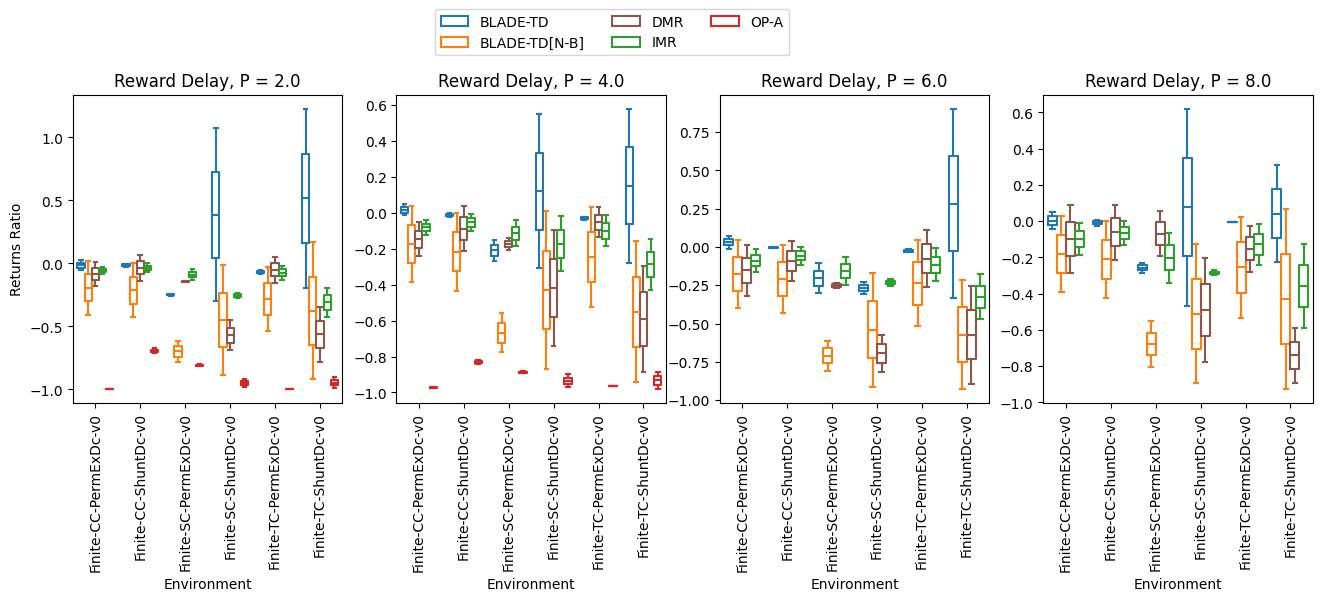

In [30]:
plot_regret(dfs_regret["sarsa"], suffix="sarsa")

## Proc Data: Run Return Matrix

For the next metrics, we need a matrix where each run is is a row, and the columns represent returns at each episode.

In [31]:
def calc_runs_returns_matrix(df_data: pd.DataFrame):
    df_raw = copy.deepcopy(
        df_data[["episode", "exp_id", "returns", "steps", "meta", "method"]]
    )

    rows = []
    experiments = df_metrics["exp_id"].unique()
    for exp_id in experiments:
        df_exp = df_raw[df_raw["exp_id"] == exp_id]
        example = df_exp.iloc[0]
        # get episodes time series
        episodes = np.array(df_exp["episode"].values)
        # matrix of return (rows) x run (columns)
        returns = np.stack(df_exp["returns"].values)
        steps = np.stack(df_exp["steps"].values)
        # sort episodes
        sorting_indices = np.argsort(episodes)
        # reorder returns by episode - earliest to latest
        sorted_returns = returns[sorting_indices, :]
        sorted_steps = steps[sorting_indices, :]
        # transpose matrix to run (rows) x return (columns)
        runs_returns_matrix = np.transpose(sorted_returns)
        runs_steps_matrix = np.transpose(sorted_steps)
        rows.append(
            {
                "exp_id": exp_id,
                "runs_returns_matrix": runs_returns_matrix,
                "runs_steps_matrix": runs_steps_matrix,
                "env_name": example["meta"]["env_spec"]["name"],
                "gamma": example["meta"]["problem_spec"]["gamma"],
                "delay_config": example["meta"]["problem_spec"]["delay_config"],
                "method": example["method"],
                "meta": example["meta"],
                "episodes": np.array(sorted(episodes)),
            }
        )
    return parse_delay_config(pd.DataFrame(rows))

In [32]:
%%time
df_runs_returns = calc_runs_returns_matrix(df_metrics)

CPU times: user 232 ms, sys: 2.13 ms, total: 234 ms
Wall time: 145 ms


In [33]:
df_runs_returns

,exp_id,runs_returns_matrix,runs_steps_matrix,env_name,gamma,method,meta,episodes,delay_type,delay_mu
0,1772983724-0067d357-Finite-CC-ShuntDc-v0,"[[632.7920527189943, 9566.302311178077, 8820.4...","[[359, 671, 50, 355, 2243, 10000, 10000, 9929,...",Finite-CC-ShuntDc-v0,0.99,FR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",None,NaN
1,1772983724-0519c138-Finite-CC-PermExDc-v0,"[[18738.478908471337, 13311.624693228332, 1302...","[[10000, 672, 9120, 2006, 1135, 8340, 10000, 5...",Finite-CC-PermExDc-v0,0.99,BLADE-TD,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,2.0
2,1772983724-0561605a-Finite-SC-PermExDc-v0,"[[12973.414088728685, 2192.8379187893247, 1524...","[[6973, 961, 180, 507, 161, 1290, 287, 497, 59...",Finite-SC-PermExDc-v0,0.99,IMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,4.0
3,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"[[27.641224155243442, 24.598766268711348, 6312...","[[20, 18, 664, 6172, 6755, 3464, 8856, 4183, 2...",Finite-TC-PermExDc-v0,0.99,IMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,8.0
4,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"[[4.69996153202516, 2.5090090483880805, 2.5261...","[[9, 9, 9, 1030, 8, 8, 11, 9, 7, 8, 13, 8, 100...",Finite-SC-ShuntDc-v0,1.00,DMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,2.0
...,...,...,...,...,...,...,...,...,...,...
223,1772983724-f768ece2-Finite-CC-PermExDc-v0,"[[35.04431434953612, 34.734215267534495, 38.34...","[[28, 28, 28, 43, 28, 28, 45, 57, 84, 47, 86, ...",Finite-CC-PermExDc-v0,0.99,OP-A,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,4.0
224,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,"[[18875.57991997372, 13046.637794550083, 6925....","[[10000, 50, 31, 6769, 125, 34, 13, 20, 20, 17...",Finite-TC-ShuntDc-v0,1.00,DMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,6.0
225,1772983724-fcaef02e-Finite-TC-PermExDc-v0,"[[71.21921572432655, 12465.53739224996, 12462....","[[49, 10000, 313, 4686, 2234, 450, 657, 8726, ...",Finite-TC-PermExDc-v0,0.99,IMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,6.0
226,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,"[[15693.938375628655, 3511.347702499489, 2487....","[[9255, 2348, 463, 861, 1131, 597, 567, 515, 4...",Finite-SC-ShuntDc-v0,1.00,BLADE-TD,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,8.0


In [34]:
np.stack(df_runs_returns.iloc[0]["runs_returns_matrix"])[:2, :]

array([[  632.79205272,  9566.30231118,  8820.46542782, 11177.09739339,
        11986.49285639, 12309.08150833, 12212.9437433 , 11268.61498423,
        11527.9088781 , 12222.07815257, 10661.46836755, 10880.34998365,
        11055.30743677, 11929.56339509, 11923.42935473, 11824.82856398,
        10888.65053709, 11291.26767543, 11309.05757292, 11454.21291757,
        11031.77714758, 11120.49885357, 11216.02587274, 11203.78580954,
        11911.75602803, 11508.299092  , 11952.53727473, 11474.0893401 ,
        12034.43369333, 11373.20390597, 12004.2050729 , 11980.17864901,
        11259.8848745 , 11288.57329584, 11650.8769734 , 11934.04070194,
        11888.98502485, 11352.62051945, 11845.10156075, 11425.58867604,
        11887.67589352, 11430.97426028, 11940.04991979, 11720.03890642,
        11884.88861132, 11806.71276147, 11923.65564821, 11781.83588373,
        11897.74378876, 11791.68559635],
       [ 6129.39195136, 15602.83284225, 11558.68319755, 12625.34059591,
         8316.97579381,

In [35]:
np.stack(df_runs_returns.iloc[0]["runs_steps_matrix"])[:2, :]

array([[  359,   671,    50,   355,  2243, 10000, 10000,  9929, 10000,
        10000,  8626, 10000,    61,  5803,  5079, 10000,  7104,  1355,
        10000, 10000,  9883, 10000,  4305,  7570,  3588,  6551,  3226,
          661, 10000, 10000,  9931,  5063,  1442, 10000,  3080, 10000,
        10000,   333,   343, 10000,  1482, 10000,  4543,   571, 10000,
          926,  4441, 10000,  1185,  2697],
       [ 3394, 10000, 10000,  2344,   318,   304, 10000,  9126,  2350,
        10000,   553,   429,   932,  1662,   235, 10000,  2419,  4573,
          285,  3766,  8305,  6977,  3160, 10000,   473,  7925, 10000,
         4707,   242, 10000, 10000,   344,  5322,  1778,   196,  3777,
         5999,  3948,  6929, 10000, 10000,  3885,  3270,   166,  6588,
         2021,  3568, 10000,  1008,  3267]])

In [36]:
def calc_ci(xs, confidence: float, method: str = "auto"):
    if method not in ("auto", "t-distribution", "normal"):
        raise ValueError("Method must be one of: {auto, t-distribution, normal}")

    # calculate mean
    mean = np.mean(xs)
    # standard error
    std_err = stats.sem(xs)

    if (method == "auto" and len(xs) < 30) or method == "t-distribution":
        form = "t-distribution"
        lb, ub = stats.t.interval(
            confidence=confidence, df=len(xs) - 1, loc=mean, scale=std_err
        )
    else:
        form = "normal"
        lb, ub = stats.norm.interval(confidence=confidence, loc=mean, scale=std_err)

    ci = np.abs(ub - mean)
    return {"ub": ub, "lb": lb, "mean": mean, "ci": ci, "ci_method": form}

In [37]:
def calc_and_format_ci(xs, confidence: float, decimals: int):
    xs = xs[~np.isnan(xs)]
    if len(xs) == 0:
        xs = [np.nan]
    ci_result = calc_ci(xs, confidence=confidence, method="auto")
    ci_fmt = " ± ".join(
        [
            str(np.around(ci_result["mean"], decimals)),
            str(np.around(ci_result["ci"], decimals)),
        ]
    )
    return ci_result, ci_fmt

In [38]:
def calc_env_method_returns_ci(
    df_results: pd.DataFrame, confidence: float, decimals: int = 4
) -> pd.DataFrame:
    """
    Calculate for each env x method x sample_size (across delays)
    """
    envs = sorted(df_results["env_name"].unique())
    methods = sorted(df_results["method"].unique())

    rows = []
    for env, method in itertools.product(envs, methods):
        df_slice = copy.copy(
            df_results[
                (df_results["env_name"] == env) & (df_results["method"] == method)
            ]
        )

        # across delays, gamma, and runs
        # shape: config x run x episodes
        returns_matrix = np.stack(df_slice["runs_returns_matrix"].values)
        # take last episode
        returns_matrix = returns_matrix[:, :, -1]
        returns = returns_matrix.flatten()
        ci_result, ci_fmt = calc_and_format_ci(
            returns, confidence=confidence, decimals=decimals
        )
        row = {"env_name": env, "method": method, "ci_fmt": ci_fmt, **ci_result}
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["env_name", "method"])

In [39]:
calc_env_method_returns_ci(df_runs_returns, confidence=0.95).pivot(
    columns="method", index="env_name", values="ci_fmt"
)[["FR", "BLADE-TD", "BLADE-TD[N-B]", "IMR", "OP-A", "DMR"]]

method,FR,BLADE-TD,BLADE-TD[N-B],IMR,OP-A,DMR
env_name,,,,,,
Finite-CC-PermExDc-v0,10798.0334 ± 434.876,10866.0807 ± 186.9226,9036.2965 ± 489.21,9974.4197 ± 261.0244,178.7667 ± 26.1559,9617.5053 ± 669.6412
Finite-CC-ShuntDc-v0,12038.1927 ± 176.6521,11938.2707 ± 105.3345,9587.0874 ± 465.7421,11427.7519 ± 177.0851,2864.5461 ± 188.4966,11274.966 ± 365.0102
Finite-SC-PermExDc-v0,1284.7223 ± 18.1024,988.2438 ± 76.2398,402.9029 ± 27.3419,1107.8956 ± 28.1599,195.8445 ± 16.3115,1082.0339 ± 54.2822
Finite-SC-ShuntDc-v0,2140.5024 ± 295.5255,1948.6805 ± 274.853,743.7764 ± 97.0978,1683.7409 ± 231.6136,94.1957 ± 6.1494,787.825 ± 106.4218
Finite-TC-PermExDc-v0,9998.1495 ± 230.3068,9682.047 ± 143.7244,7589.9708 ± 494.2607,8998.4448 ± 229.9624,205.7151 ± 33.1513,9235.1305 ± 451.5681
Finite-TC-ShuntDc-v0,3410.6651 ± 686.5044,3205.0241 ± 400.2646,844.0654 ± 105.8117,1990.1528 ± 288.411,115.1943 ± 7.844,795.8106 ± 115.3437


In [40]:
print(
    calc_env_method_returns_ci(
        df_runs_returns[
            df_runs_returns["method"].apply(lambda met: met not in set(["FR"]))
        ],
        confidence=0.95,
    )
    .pivot(columns="method", index="env_name", values="ci_fmt")[
        reversed(["BLADE-TD", "IMR", "OP-A", "DMR"])
    ]
    .to_latex()
)

\begin{tabular}{lllll}
\toprule
method & DMR & OP-A & IMR & BLADE-TD \\
env_name &  &  &  &  \\
\midrule
Finite-CC-PermExDc-v0 & 9617.5053 ± 669.6412 & 178.7667 ± 26.1559 & 9974.4197 ± 261.0244 & 10866.0807 ± 186.9226 \\
Finite-CC-ShuntDc-v0 & 11274.966 ± 365.0102 & 2864.5461 ± 188.4966 & 11427.7519 ± 177.0851 & 11938.2707 ± 105.3345 \\
Finite-SC-PermExDc-v0 & 1082.0339 ± 54.2822 & 195.8445 ± 16.3115 & 1107.8956 ± 28.1599 & 988.2438 ± 76.2398 \\
Finite-SC-ShuntDc-v0 & 787.825 ± 106.4218 & 94.1957 ± 6.1494 & 1683.7409 ± 231.6136 & 1948.6805 ± 274.853 \\
Finite-TC-PermExDc-v0 & 9235.1305 ± 451.5681 & 205.7151 ± 33.1513 & 8998.4448 ± 229.9624 & 9682.047 ± 143.7244 \\
Finite-TC-ShuntDc-v0 & 795.8106 ± 115.3437 & 115.1943 ± 7.844 & 1990.1528 ± 288.411 & 3205.0241 ± 400.2646 \\
\bottomrule
\end{tabular}



## Returns AUC

In [41]:
def calc_returns_auc(df_data: pd.DataFrame):
    def calc_auc(runs_returns_matrix):
        runs_returns_matrix = np.stack(runs_returns_matrix)
        timesteps = np.arange(runs_returns_matrix.shape[1])
        return np.trapz(runs_returns_matrix, x=timesteps, axis=1)

    df_raw = copy.deepcopy(df_data[["exp_id", "runs_returns_matrix", "meta", "method"]])
    df_raw["auc"] = df_raw["runs_returns_matrix"].apply(calc_auc)
    df_raw = extract_salient_meta_fields(df_raw)
    del df_raw["runs_returns_matrix"]
    del df_raw["meta"]
    return df_raw

In [42]:
df_returns_auc = calc_returns_auc(df_runs_returns)

In [43]:
df_returns_auc

,exp_id,method,auc,env_name,env_args,feats_name,feats_args,gamma,delay_type,delay_mu
0,1772983724-0067d357-Finite-CC-ShuntDc-v0,FR,"[558251.3979243758, 561606.6508940419, 554812....",Finite-CC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,None,NaN
1,1772983724-0519c138-Finite-CC-PermExDc-v0,BLADE-TD,"[554320.3979874734, 561428.4087349675, 558309....",Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,2.0
2,1772983724-0561605a-Finite-SC-PermExDc-v0,IMR,"[61310.52878356463, 40302.54478545836, 38366.5...",Finite-SC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,4.0
3,1772983724-0c1a6486-Finite-TC-PermExDc-v0,IMR,"[372726.2522583812, 379117.76602539857, 391605...",Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,8.0
4,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,DMR,"[26481.725989145718, 43361.98195813237, 29726....",Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,2.0
...,...,...,...,...,...,...,...,...,...,...
223,1772983724-f768ece2-Finite-CC-PermExDc-v0,OP-A,"[8576.975691499469, 8038.51853020173, 9234.899...",Finite-CC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",spliced-tiles,{'tiling_dim': 4.0},0.99,clipped-poisson,4.0
224,1772983724-fa9e2560-Finite-TC-ShuntDc-v0,DMR,"[137134.85381777788, 134543.9033722298, 75741....",Finite-TC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,6.0
225,1772983724-fcaef02e-Finite-TC-PermExDc-v0,IMR,"[406878.0292809923, 423472.9575189506, 345153....",Finite-TC-PermExDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",tiles,{'tiling_dim': 3.0},0.99,clipped-poisson,6.0
226,1772983724-fe0e2030-Finite-SC-ShuntDc-v0,BLADE-TD,"[74223.2108329499, 73400.20042197294, 69907.37...",Finite-SC-ShuntDc-v0,"{'constraint_violation_reward': -10.0, 'emit_s...",scale,None,1.00,clipped-poisson,8.0


In [44]:
def plot_auc(df_data: pd.DataFrame):
    df_raw = copy.deepcopy(df_data)
    df_metric = df_raw.explode("auc")
    df_metric = df_metric[~pd.isnull(df_metric["delay_mu"])]

    delays = sorted(df_metric["delay_mu"].unique())
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(delays),
        figsize=(4 * len(delays), 4),
        sharey=False,
    )

    legend_shown = False
    for ax, delay in zip(axes.flatten(), delays):
        df_plot = df_metric[df_metric["delay_mu"] == delay]
        sns.boxplot(
            df_plot,
            x="env_name",
            y="auc",
            hue="method",
            palette=METHODS_PALETTES,
            fill=False,
            ax=ax,
        )
        ax.tick_params(axis="x", labelrotation=90)
        ax.set_xlabel("Environment")
        ax.set_title(f"Reward Delay, P = {delay}")
        if legend_shown is False:
            legend_shown = True
            ax.set_ylabel("Returns AUC")
            ax.legend(
                loc="upper center",
                bbox_to_anchor=(len(delays) / 2.0, 1.3),
                ncol=3,
                fancybox=True,
            )
        else:
            ax.set(ylabel=None)
            ax.legend().set_visible(False)

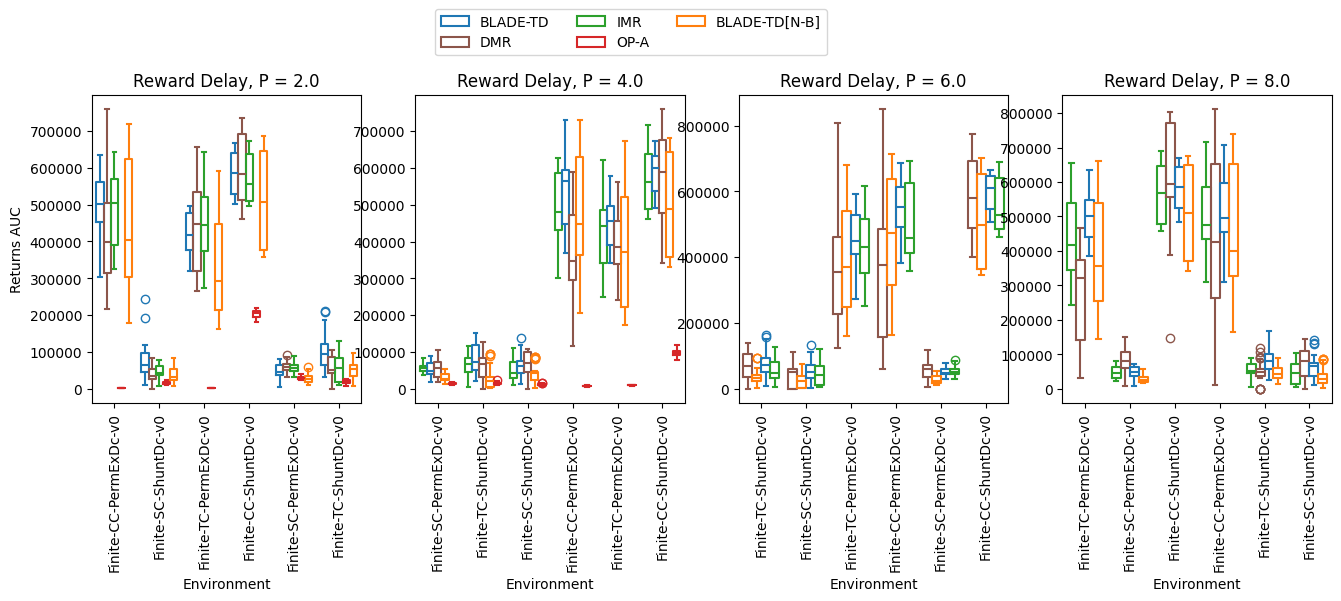

In [45]:
plot_auc(df_returns_auc)

## Time to Threshold Returns

In [46]:
def plot_delay_perf_curves(df_data, metric: str):
    df_raw = df_data[["env_name", "gamma", "delay_mu", "method", metric]]
    df_raw = copy.deepcopy(df_raw[df_raw["method"] != "FR"])
    palette = {key: pl for key, pl in METHODS_PALETTES.items() if key != "FR"}
    envs = sorted(df_raw["env_name"].unique())
    ncols = len(envs)
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(4 * ncols, 4))

    for env, ax in zip(envs, axes.flatten()):
        df_slice = df_raw[df_raw["env_name"] == env]
        sns.lineplot(
            data=df_slice,
            x="delay_mu",
            y=metric,
            hue="method",
            style="method",
            palette=palette,
            markers=True,
            dashes=False,
            ax=ax,
        )
        ax.set_title(env)

In [47]:
def calc_threshold_metrics(df_data, threshold: float = 0.9):
    fr_mask = df_data["method"] == "FR"
    df_fr = df_data[fr_mask]
    df_other = df_data[~fr_mask]

    rows = []
    # each row is a config: env x gamma x method x delay
    for row in df_other.to_dict("records"):
        # get baseline returns
        df_fr_slice = df_fr[
            (df_fr["env_name"] == row["env_name"]) & (df_fr["gamma"] == row["gamma"])
        ]
        fr_returns_matrix = np.stack(df_fr_slice.iloc[0]["runs_returns_matrix"])
        # returns at the last step
        fr_mean_returns_last_ep = np.mean(fr_returns_matrix[:, -1])
        method_returns_matrix = np.stack(row["runs_returns_matrix"])
        # Positive returns
        if fr_mean_returns_last_ep > 0:
            bound = threshold * fr_mean_returns_last_ep
        else:
            bound = (2 - threshold) * fr_mean_returns_last_ep
        # which episodic returns are above the treshold
        ep_above_threshold_mask = method_returns_matrix >= bound
        # which runs reach the threshold
        ep_that_reach_threshod_mask = np.sum(ep_above_threshold_mask, axis=1) > 0
        # first episode reaching threshold in each run
        first_ep_reaching_threshold = np.argmax(ep_above_threshold_mask, axis=1)
        # In runs reaching threshold, average episode
        mean_time_to_reach_threshold = np.mean(
            first_ep_reaching_threshold[ep_that_reach_threshod_mask]
        )
        # percentage of episodes tha reach threshold
        ep_that_reach_threshod = np.sum(ep_that_reach_threshod_mask) / len(
            ep_that_reach_threshod_mask
        )
        # time perce of episodes spent above threshold
        time_above_threshold = np.mean(
            np.sum(
                # use abs for negative returns
                ep_above_threshold_mask >= bound,
                axis=1,
            )
            / method_returns_matrix.shape[1]
        )
        # approx time spent within range of threshold
        # runs x episodes
        entry = copy.deepcopy(row)
        entry["mean_time_to_reach_threshold"] = mean_time_to_reach_threshold
        entry["perc_turns_reaching_threshold"] = ep_that_reach_threshod
        entry["time_above_threshold"] = np.mean(
            np.sum(
                # use abs for negative returns
                # TODO: check if pos or negative; differen top
                method_returns_matrix >= bound,
                axis=1,
            )
            / method_returns_matrix.shape[1]
        )
        rows.append(entry)
    return pd.DataFrame(rows)

In [48]:
def calc_env_method_return_perctile_ci(
    df_results: pd.DataFrame, confidence: float, decimals: int = 4
) -> pd.DataFrame:
    """
    Calculate for each env x method x sample_size (across delays)
    """
    envs = sorted(df_results["env_name"].unique())
    methods = sorted(df_results["method"].unique())

    rows = []
    for env, method in itertools.product(envs, methods):
        df_slice = copy.copy(
            df_results[
                (df_results["env_name"] == env) & (df_results["method"] == method)
            ]
        )

        # across delays, gamma, and runs
        values = df_slice["time_above_threshold"].values
        ci_result, ci_fmt = calc_and_format_ci(
            values, confidence=confidence, decimals=decimals
        )
        row = {"env_name": env, "method": method, "ci_fmt": ci_fmt, **ci_result}
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["env_name", "method"])

In [49]:
df_threshold_metrics = calc_threshold_metrics(df_runs_returns)

/Users/guilherme/Code/research.phd/drmdp-fnapprox/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/guilherme/Code/research.phd/drmdp-fnapprox/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [50]:
df_threshold_metrics.head()

,exp_id,runs_returns_matrix,runs_steps_matrix,env_name,gamma,method,meta,episodes,delay_type,delay_mu,mean_time_to_reach_threshold,perc_turns_reaching_threshold,time_above_threshold
0,1772983724-0519c138-Finite-CC-PermExDc-v0,"[[18738.478908471337, 13311.624693228332, 1302...","[[10000, 672, 9120, 2006, 1135, 8340, 10000, 5...",Finite-CC-PermExDc-v0,0.99,BLADE-TD,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,2.0,7.000000,1.00,0.587
1,1772983724-0561605a-Finite-SC-PermExDc-v0,"[[12973.414088728685, 2192.8379187893247, 1524...","[[6973, 961, 180, 507, 161, 1290, 287, 497, 59...",Finite-SC-PermExDc-v0,0.99,IMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,4.0,1.052632,0.95,0.201
2,1772983724-0c1a6486-Finite-TC-PermExDc-v0,"[[27.641224155243442, 24.598766268711348, 6312...","[[20, 18, 664, 6172, 6755, 3464, 8856, 4183, 2...",Finite-TC-PermExDc-v0,0.99,IMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,8.0,1.200000,0.75,0.081
3,1772983724-0ee19c07-Finite-SC-ShuntDc-v0,"[[4.69996153202516, 2.5090090483880805, 2.5261...","[[9, 9, 9, 1030, 8, 8, 11, 9, 7, 8, 13, 8, 100...",Finite-SC-ShuntDc-v0,1.00,DMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,2.0,2.058824,0.85,0.347
4,1772983724-0f9a86eb-Finite-TC-ShuntDc-v0,"[[14.03565307320308, 5.077076674412511, 5.3443...","[[13, 7, 11, 9, 8, 7, 7, 8, 7, 9, 8, 9, 7, 7, ...",Finite-TC-ShuntDc-v0,0.99,DMR,"{'context': {'dummy': 0}, 'exp_id': '177298372...","[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1...",clipped-poisson,6.0,0.111111,0.45,0.024


In [51]:
calc_env_method_return_perctile_ci(df_threshold_metrics, confidence=0.95).pivot(
    columns="method", index="env_name", values="ci_fmt"
)

/Users/guilherme/Code/research.phd/drmdp-fnapprox/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/Users/guilherme/Code/research.phd/drmdp-fnapprox/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


method,BLADE-TD,BLADE-TD[N-B],DMR,IMR,OP-A
env_name,,,,,
Finite-CC-PermExDc-v0,0.6786 ± 0.0509,0.456 ± 0.3189,0.4188 ± 0.1213,0.5509 ± 0.159,0.0 ± nan
Finite-CC-ShuntDc-v0,0.8716 ± 0.0986,0.5226 ± 0.4106,0.6247 ± 0.2777,0.6435 ± 0.3086,0.0093 ± 0.0152
Finite-SC-PermExDc-v0,0.5825 ± 0.0757,0.0735 ± 0.0281,0.5249 ± 0.0869,0.4167 ± 0.2177,0.048 ± 0.0481
Finite-SC-ShuntDc-v0,0.3542 ± 0.2412,0.2692 ± 0.2271,0.2942 ± 0.2532,0.2792 ± 0.1401,0.0253 ± 0.0178
Finite-TC-PermExDc-v0,0.628 ± 0.118,0.4198 ± 0.3378,0.3935 ± 0.1598,0.5019 ± 0.3153,0.0 ± nan
Finite-TC-ShuntDc-v0,0.3434 ± 0.236,0.265 ± 0.2425,0.2818 ± 0.2498,0.3008 ± 0.2384,0.025 ± 0.023


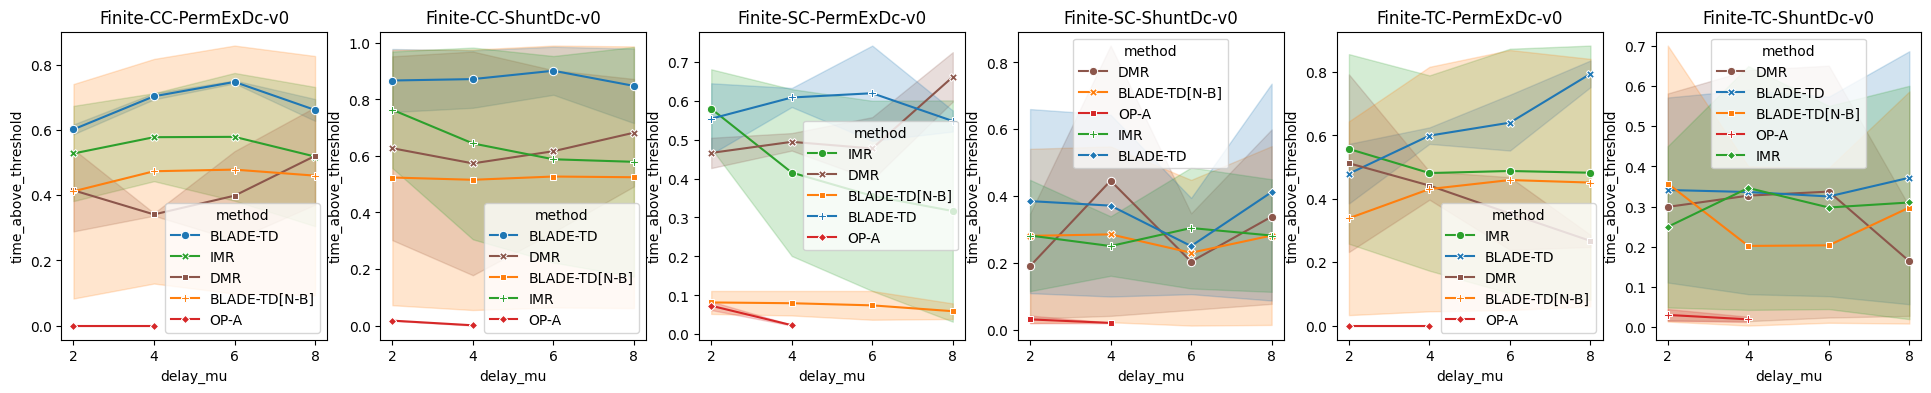

In [52]:
plot_delay_perf_curves(df_threshold_metrics, "time_above_threshold")

Most of these environments have high variance in their starts, or get worse before they get good.
Measuring time to reach a threshold result is unreliable.

## Method Efficiency per Delay

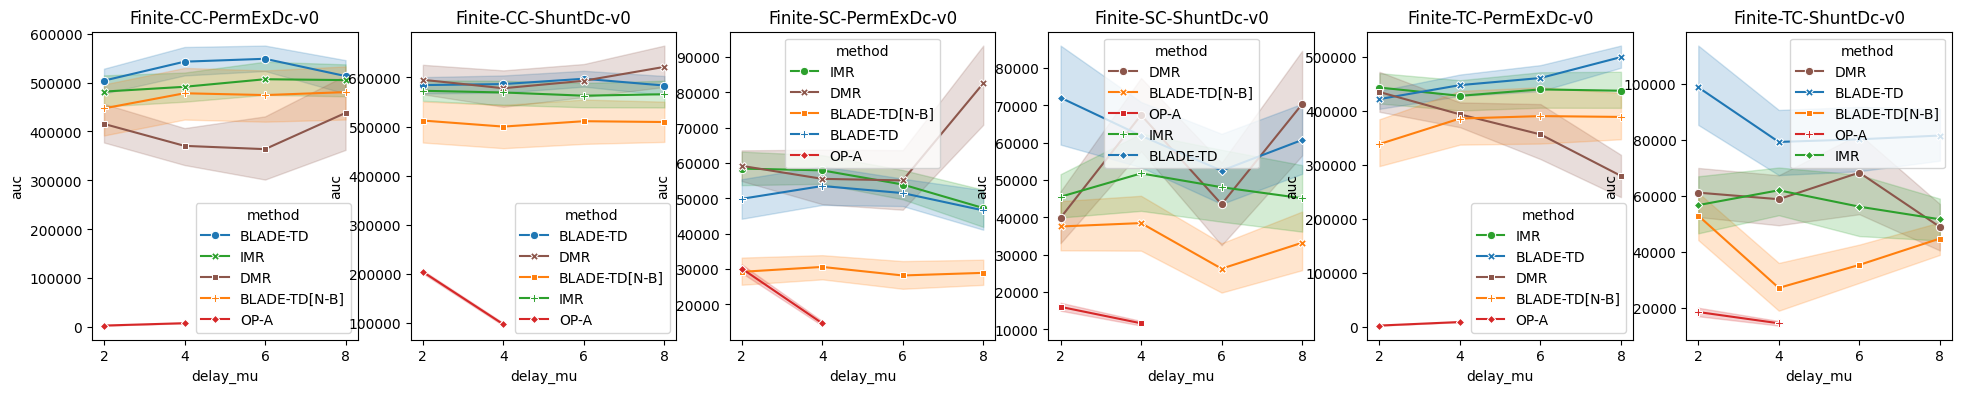

In [53]:
plot_delay_perf_curves(df_returns_auc.explode("auc").reset_index(), metric="auc")

## Returns Interquartile Mean @ K (IQM@K)

In [54]:
def calc_returns_iqm(df_data, confidence: float, decimals: int = 4):
    def calc_iqm_returns(runs_returns_matrix):
        runs_returns_matrix = np.stack(runs_returns_matrix)
        runs_returns = runs_returns_matrix[:, -1]
        return stats.trimboth(runs_returns, proportiontocut=0.25)

    df_raw = copy.deepcopy(df_data)
    df_raw["iqm_returns"] = df_raw["runs_returns_matrix"].apply(calc_iqm_returns)

    envs = sorted(df_raw["env_name"].unique())
    methods = sorted(df_raw["method"].unique())
    rows = []
    for env, method in itertools.product(envs, methods):
        df_slice = df_raw[(df_raw["env_name"] == env) & (df_raw["method"] == method)]
        # across delays, gamma, and runs
        values = np.stack(df_slice["iqm_returns"]).flatten()
        ci_result, ci_fmt = calc_and_format_ci(
            values, confidence=confidence, decimals=decimals
        )
        row = {"env_name": env, "method": method, "ci_fmt": ci_fmt, **ci_result}
        rows.append(row)

    return pd.DataFrame(rows)

In [55]:
calc_returns_iqm(df_runs_returns, confidence=0.95).pivot(
    columns="method", index="env_name", values="ci_fmt"
)

method,BLADE-TD,BLADE-TD[N-B],DMR,FR,IMR,OP-A
env_name,,,,,,
Finite-CC-PermExDc-v0,10984.6041 ± 175.5686,9214.7004 ± 704.2074,9244.7245 ± 751.7846,10776.2454 ± 471.0871,10070.9863 ± 332.4599,179.3905 ± 35.0967
Finite-CC-ShuntDc-v0,11921.1989 ± 138.9903,9582.6796 ± 658.1799,11229.661 ± 475.8643,12031.7371 ± 232.8826,11397.6825 ± 242.1191,2896.9335 ± 257.667
Finite-SC-PermExDc-v0,1147.1564 ± 64.8352,395.5335 ± 33.819,1144.1025 ± 47.3653,1289.1088 ± 16.1876,1126.2385 ± 36.8382,193.2965 ± 17.7005
Finite-SC-ShuntDc-v0,1606.3732 ± 169.2626,747.5845 ± 131.2553,769.3979 ± 137.7288,2199.2577 ± 438.8581,1648.0017 ± 294.4427,92.9704 ± 7.5682
Finite-TC-PermExDc-v0,9725.2601 ± 133.9875,7609.0139 ± 692.4754,8894.3245 ± 445.8031,9980.3255 ± 276.0311,8990.1444 ± 309.7141,214.271 ± 45.8392
Finite-TC-ShuntDc-v0,2922.3136 ± 348.5279,866.8973 ± 139.4334,782.3038 ± 149.4961,3624.2794 ± 1064.4353,1899.2214 ± 344.6798,113.3386 ± 10.2006


## Returns Running Coefficient of Variation (CV)

In [56]:
def calc_returns_cv(
    df_data, confidence: float, decimals: int = 4, window_size: int = 5
):
    def calc_rolling_cv(sequence):
        # Convert to pandas series for easy rolling ops
        series = pd.Series(sequence)
        # CV = Rolling Std / Rolling Mean
        res = series.rolling(window_size).std() / series.rolling(window_size).mean()
        return res.fillna(0).values

    def returns_cv(runs_returns_matrix):
        runs_returns_matrix = np.stack(runs_returns_matrix)
        rows = []
        for i in range(runs_returns_matrix.shape[0]):
            row = calc_rolling_cv(runs_returns_matrix[i])
            rows.append(np.mean(row))
        return np.array(rows)

    df_raw = copy.deepcopy(df_data)
    df_raw["returns_rolling_cv"] = df_raw["runs_returns_matrix"].apply(returns_cv)

    envs = sorted(df_raw["env_name"].unique())
    methods = sorted(df_raw["method"].unique())
    rows = []
    for env, method in itertools.product(envs, methods):
        df_slice = df_raw[(df_raw["env_name"] == env) & (df_raw["method"] == method)]
        # across delays, gamma, and runs
        values = np.stack(df_slice["returns_rolling_cv"]).flatten()
        ci_result, ci_fmt = calc_and_format_ci(
            values, confidence=confidence, decimals=decimals
        )
        row = {"env_name": env, "method": method, "ci_fmt": ci_fmt, **ci_result}
        rows.append(row)
    return pd.DataFrame(rows)

In [57]:
calc_returns_cv(df_runs_returns, confidence=0.95).pivot(
    columns="method", index="env_name", values="ci_fmt"
)

method,BLADE-TD,BLADE-TD[N-B],DMR,FR,IMR,OP-A
env_name,,,,,,
Finite-CC-PermExDc-v0,0.1601 ± 0.0144,0.1694 ± 0.0164,0.5251 ± 0.0447,0.1697 ± 0.0354,0.1541 ± 0.0128,0.0902 ± 0.0118
Finite-CC-ShuntDc-v0,0.0448 ± 0.0029,0.0486 ± 0.0031,0.1062 ± 0.0154,0.045 ± 0.0038,0.0453 ± 0.003,0.1048 ± 0.0141
Finite-SC-PermExDc-v0,0.4251 ± 0.0429,0.3061 ± 0.019,0.447 ± 0.0495,0.0671 ± 0.0156,0.234 ± 0.0225,0.1795 ± 0.0187
Finite-SC-ShuntDc-v0,0.5856 ± 0.0556,0.5927 ± 0.0539,0.6421 ± 0.079,0.1265 ± 0.0302,0.5634 ± 0.0584,0.1688 ± 0.0158
Finite-TC-PermExDc-v0,0.1537 ± 0.0117,0.1946 ± 0.0132,0.4227 ± 0.0387,0.1135 ± 0.0141,0.1246 ± 0.0105,0.1224 ± 0.0159
Finite-TC-ShuntDc-v0,0.6026 ± 0.0504,0.609 ± 0.0643,0.777 ± 0.0776,0.2247 ± 0.0517,0.4876 ± 0.0503,0.1638 ± 0.0165


## For Print

### Relative Regret - Returns Ratio

In [58]:
def print_regret(
    df_data, suffix=None, method_filter_fn=lambda met: True, output_dir="figures/regret"
):
    df_raw = copy.deepcopy(
        df_data[["env_name", "method", "delay_type", "delay_mu", "relative_regret"]]
    )
    df_raw = df_raw[df_raw["method"].apply(method_filter_fn)]
    if len(df_raw) == 0:
        return
    rps = sorted(df_raw["delay_mu"].unique())

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for rp in rps:
        df_plot = df_raw[df_raw["delay_mu"] == rp]
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        sns.boxplot(
            df_plot,
            x="env_name",
            y="relative_regret",
            hue="method",
            palette=METHODS_PALETTES,
            ax=ax,
            fill=False,
        )
        ax.tick_params(axis="x", labelrotation=90)
        ax.set_xlabel("Environment")
        ax.set_ylabel("Returns Ratio")
        ax.set_title(f"Reward Period, P = {rp}")
        name = f"regret_{suffix}_rp{rp}.pdf"
        path = os.path.join(output_dir, name)
        plt.savefig(path, dpi=300, format="pdf", bbox_inches="tight")

In [59]:
print_regret(
    filter_envs(
        dfs_regret["sarsa"],
        envs=set(["GridWorld-v0", "IceWorld-v0", "MountainCar-v0", "RedGreen-v0"]),
    ),
    suffix="gym_sarsa",
)

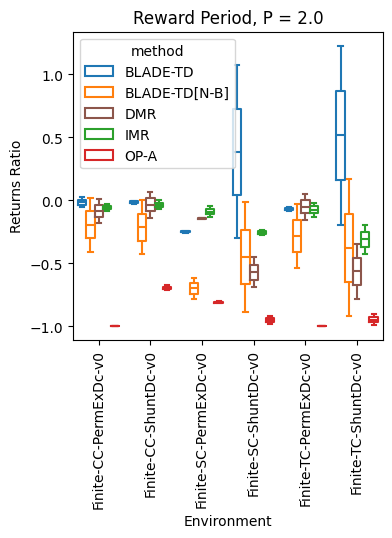

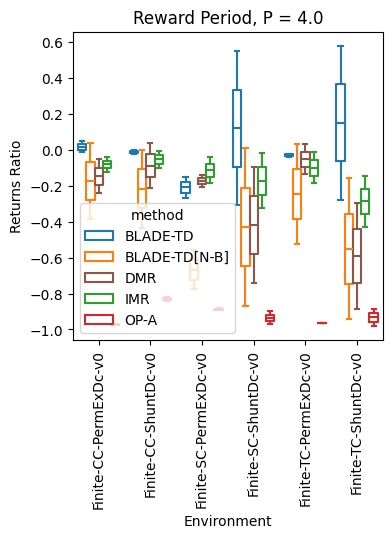

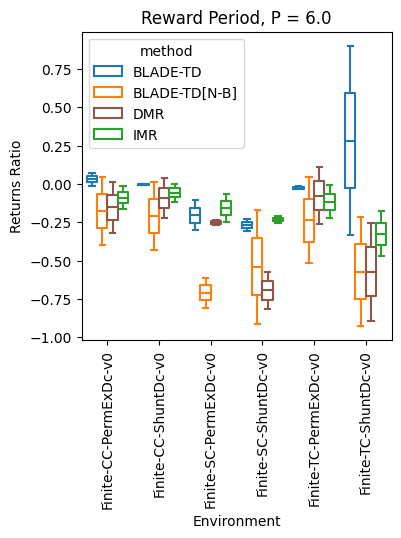

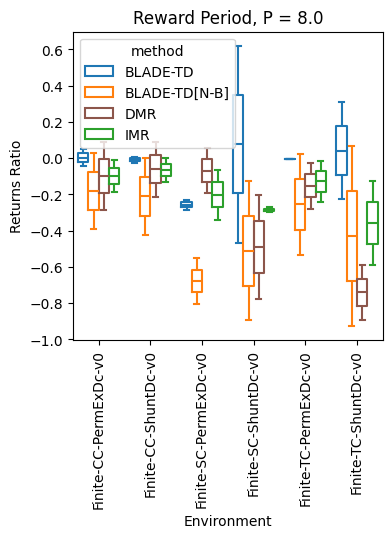

In [60]:
print_regret(
    filter_envs(
        dfs_regret["sarsa"],
        envs=set(
            [
                "Finite-CC-PermExDc-v0",
                "Finite-CC-ShuntDc-v0",
                "Finite-SC-PermExDc-v0",
                "Finite-SC-ShuntDc-v0",
                "Finite-TC-PermExDc-v0",
                "Finite-TC-ShuntDc-v0",
            ]
        ),
    ),
    suffix="gem_sarsa",
)

### Regret per Env

In [61]:
def plot_regret_dist(df_data, suffix, output_dir="figures/regret"):
    env_names = sorted(df_data["env_name"].unique())
    for env_name in env_names:
        df_slice = df_data[df_data["env_name"] == env_name]
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        sns.kdeplot(
            data=df_slice,
            x="relative_regret",
            hue="method",
            palette=METHODS_PALETTES,
            fill=False,
            ax=ax,
        )
        ax.set_xlabel("Returns Ratio")
        ax.set_ylabel("Density")
        ax.set_title(f"Environment = {env_name}")
        name = f"regret_{suffix}_env_{env_name}.pdf"
        path = os.path.join(output_dir, name)
        plt.savefig(path, dpi=300, format="pdf", bbox_inches="tight")

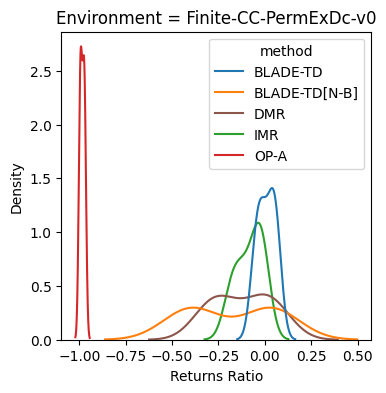

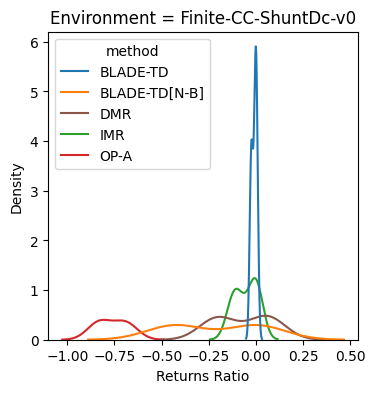

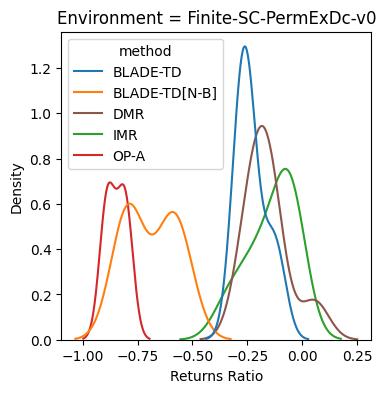

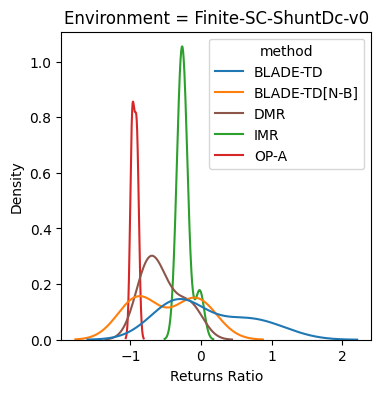

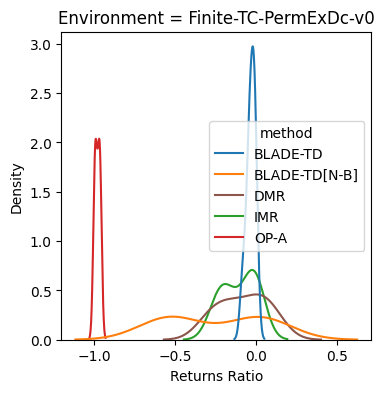

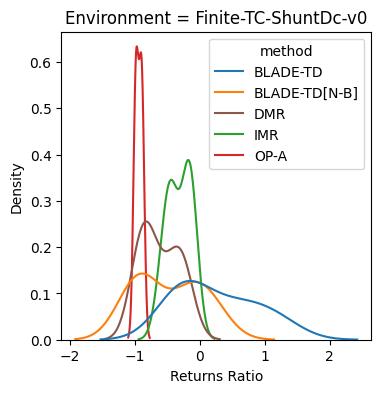

In [62]:
plot_regret_dist(dfs_regret["sarsa"], "sarsa")